## 1. Introduzione

In questo tutorial:
1. **Caricheremo** il dataset MNIST e vedremo la sua struttura.
2. **Preprocesseremo** i dati in maniera adeguata per la rete neurale.
3. **Definiremo** una rete neurale semplice (modello sequenziale).
4. **Addestreremo** la rete.
5. **Valuteremo** i risultati su dati di test.
6. **Osserveremo** qualche predizione della nostra rete e alcune statistiche.

> **Obiettivo**: classificare correttamente le cifre scritte a mano (0-9) con un’accuratezza ragionevole, sfruttando un MLP di base.

## 2. Setup e import delle librerie

Assicuriamoci di avere installato TensorFlow e le altre librerie necessarie. Su Google Colab queste librerie sono già installate di default; in un ambiente locale invece si può installare TensorFlow tramite `pip install tensorflow`.

In [21]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix
import seaborn as sns

import numpy as np
import matplotlib.pyplot as plt

import random

- **tensorflow**: framework per il deep learning.
- **keras**: interfaccia di alto livello integrata in TensorFlow.
- **layers**: contiene i vari livelli (Dense, Conv2D, ecc.) per costruire la rete.
- **numpy**: libreria base per le operazioni numeriche e matriciali in Python.
- **matplotlib**: libreria per le visualizzazioni grafiche.

## 3. Caricamento del dataset MNIST

Keras fornisce direttamente il dataset MNIST tramite un comodo comando:

In [22]:
# Carichiamo il dataset MNIST da Keras
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Stampa delle dimensioni vettoriali (shape) dei dataframe train e test
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)


### 3.1 Osserviamo un esempio

MNIST contiene immagini in scala di grigi 28x28. Vediamo come appare una cifra:

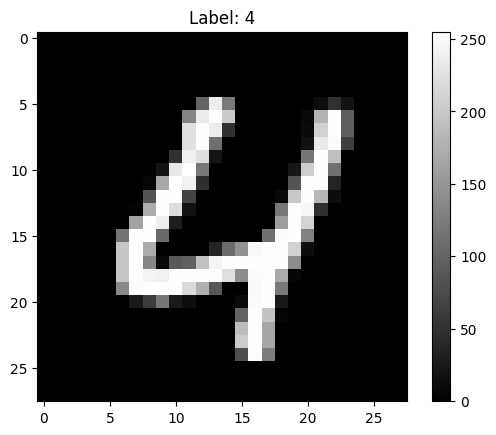

In [23]:
plt.imshow(x_train[64], cmap='gray')
plt.title(f"Label: {y_train[64]}")
plt.colorbar()
plt.show()

## 4. Preprocessing dei dati

Per utilizzare i dati in una rete neurale, conviene normalizzarli (o scalarli) in modo che abbiano valori tra 0 e 1, così che il modello converga più facilmente in fase di addestramento.

1. Convertiamo i numeri (originariamente tra 0 e 255) in float e li dividiamo per 255.0.
2. Appiattiamo le immagini 2D in un vettore 1D di lunghezza 784 (28x28) perché il nostro MLP riceverà in input un vettore.

In [24]:
# Convertiamo in float e normalizziamo
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Appiattiamo (flatten) ogni immagine 28x28 in un vettore di 784 elementi
x_train = x_train.reshape((-1, 28*28))
x_test = x_test.reshape((-1, 28*28))

# Le etichette (label) sono numeri interi da 0 a 9; Keras può lavorare con questi come interi
print("Nuova forma x_train:", x_train.shape)
print("Nuova forma x_test:", x_test.shape)

Nuova forma x_train: (60000, 784)
Nuova forma x_test: (10000, 784)


## 5. Definizione del modello

Creiamo un **modello sequenziale** di Keras. L’architettura proposta è molto semplice:

1. Uno strato Dense (denso/fully-connected) con ad esempio 128 neuroni e funzione di attivazione `relu`.
2. Uno strato Dense finale con 10 neuroni (uno per ogni classe) e attivazione `softmax`, che ci restituirà le probabilità per ciascuna delle 10 cifre.

In [25]:
model = models.Sequential([
    layers.Input(shape=(784,)),  # Layer di input: vettore di input di dimensione 784 (ad esempio, immagini 28x28 pixel appiattite)
    layers.Dense(128, activation='relu'),  # Primo layer denso con 128 neuroni e attivazione ReLU
    layers.Dense(10, activation='softmax')  # Layer di output con 10 neuroni (uno per ogni classe) e attivazione softmax per la classificazione
])

### 5.1 Compilazione del modello

Per poter addestrare il modello, occorre specificare:
- **optimizer**: algoritmo di ottimizzazione (ad es. `adam` è una scelta comune).
- **loss function**: funzione di costo da minimizzare (ad es. `sparse_categorical_crossentropy` per classificazione multiclasse con label intere).
- **metriche**: metriche da tenere sotto controllo durante il training, come la `accuracy`.

In [26]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # ex. MAE, RMSE, sparse_categorical_crossentropy, categorical_crossentropy, MSE
    metrics=['accuracy'] # ex. accuracy, precision, recall, f1-score, AUC
)

## 6. Addestramento (training)

Richiamiamo ora il metodo `fit` di Keras, specificando:
- I dati di training (`x_train`, `y_train`).
- Il numero di epoche (`epochs`) cioè quante volte vedremo l’intero dataset.
- Eventualmente la dimensione del batch (`batch_size`) per l’aggiornamento dei pesi (solitamente 32 o 64).

Keras mostrerà l’andamento di **loss** e **accuracy** (sia su training che su validation) ad ogni epoca.

In [27]:
history = model.fit(
    x_train, y_train,
    epochs=5,            # provare anche a mettere più epoche, es. 10
    batch_size=64,
    validation_split=0.1 # usiamo il 10% dei dati di training come validation set
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9109 - loss: 0.3197 - val_accuracy: 0.9582 - val_loss: 0.1480
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9584 - loss: 0.1446 - val_accuracy: 0.9708 - val_loss: 0.1069
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9704 - loss: 0.1014 - val_accuracy: 0.9755 - val_loss: 0.0902
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9775 - loss: 0.0774 - val_accuracy: 0.9712 - val_loss: 0.1007
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9811 - loss: 0.0624 - val_accuracy: 0.9748 - val_loss: 0.0785


In [28]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305,312 (1.16 MB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 203,542 (795.09 KB)

## 7. Valutazione sul test set

Una volta terminato l’addestramento, valutiamo il modello sui dati di **test** mai visti. Questo ci fornirà una stima della capacità di generalizzare, cioè quanto bene la rete riesce a classificare cifre che non ha mai visto in fase di training.

In [31]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=1)
print(f"Loss sul test set: {test_loss:.4f}")
print(f"Accuracy sul test set: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9738 - loss: 0.0870
Loss sul test set: 0.0870
Accuracy sul test set: 0.9738


## 8. Analisi dei risultati e predizioni

### 8.1 Grafico dell’andamento di loss e accuracy

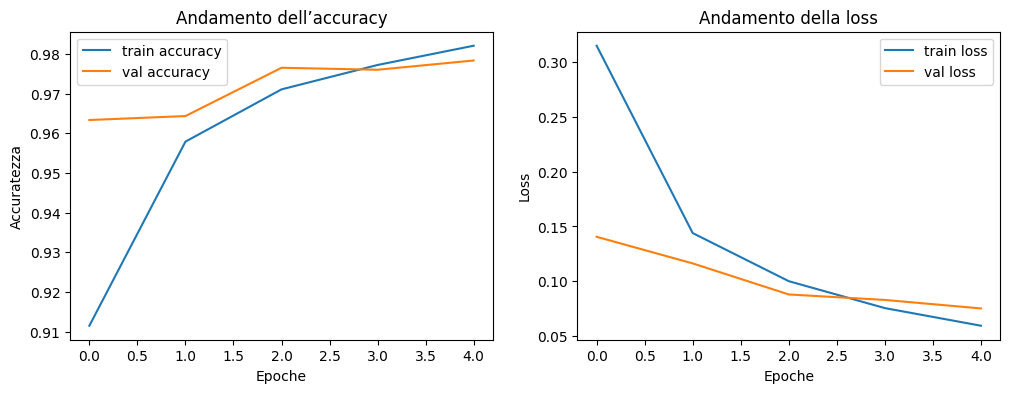

In [10]:
def plot_history(history):
    # Accuracy
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='train accuracy')
    plt.plot(history.history['val_accuracy'], label='val accuracy')
    plt.xlabel('Epoche')
    plt.ylabel('Accuratezza')
    plt.legend()
    plt.title('Andamento dell’accuracy')

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='train loss')
    plt.plot(history.history['val_loss'], label='val loss')
    plt.xlabel('Epoche')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Andamento della loss')

    plt.show()

plot_history(history)

### Visualizzazione delle metriche di addestramento

Dopo aver addestrato il modello, è fondamentale analizzare l'andamento della **loss** e dell'**accuracy** per capire come sta imparando la rete neurale.

Nel codice appena eseguito:
- Abbiamo estratto i valori di `loss` e `accuracy` dal dizionario `history.history` che contiene i risultati di ogni epoca.
- Abbiamo plottato due grafici:
  1. **Loss durante l'addestramento**: mostra come la funzione di perdita cambia ad ogni epoca per il training set e il validation set.
     - Un buon modello dovrebbe mostrare una loss decrescente e stabile.
     - Un aumento della loss nel validation set può indicare **overfitting**, ovvero il modello sta "memorizzando" i dati di training invece di generalizzare.

  2. **Accuracy durante l'addestramento**: rappresenta l'accuratezza raggiunta ad ogni epoca, sia sul training set che sul validation set.
     - L'accuracy misura la percentuale di predizioni corrette.
     - Un'accuratezza che cresce rapidamente nel training set ma non migliora nel validation set indica, anche qui, un possibile overfitting.

Questi grafici servono a:
- **Monitorare l'addestramento**.
- **Ottimizzare gli iperparametri** (ad esempio, il numero di epoche, la dimensione del batch o il learning rate).
- **Identificare problemi** come l'overfitting o l'underfitting.

---

Se vediamo che la loss nel validation set smette di migliorare o inizia ad aumentare, potremmo:
- Aumentare o diminuire il numero di epoche.
- Usare tecniche di regularizzazione come il Dropout.
- Regolare il learning rate.
- Aumentare il dataset o usare data augmentation.

### 8.2 Predizioni su nuove immagini

Proviamo a fare qualche predizione casuale nel test set. Estraiamo alcune immagini (in realtà, ricordiamoci che abbiamo appiattito i dati, quindi per la visualizzazione dovremo `reshapearle` a 28x28) e verifichiamo la risposta della rete.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


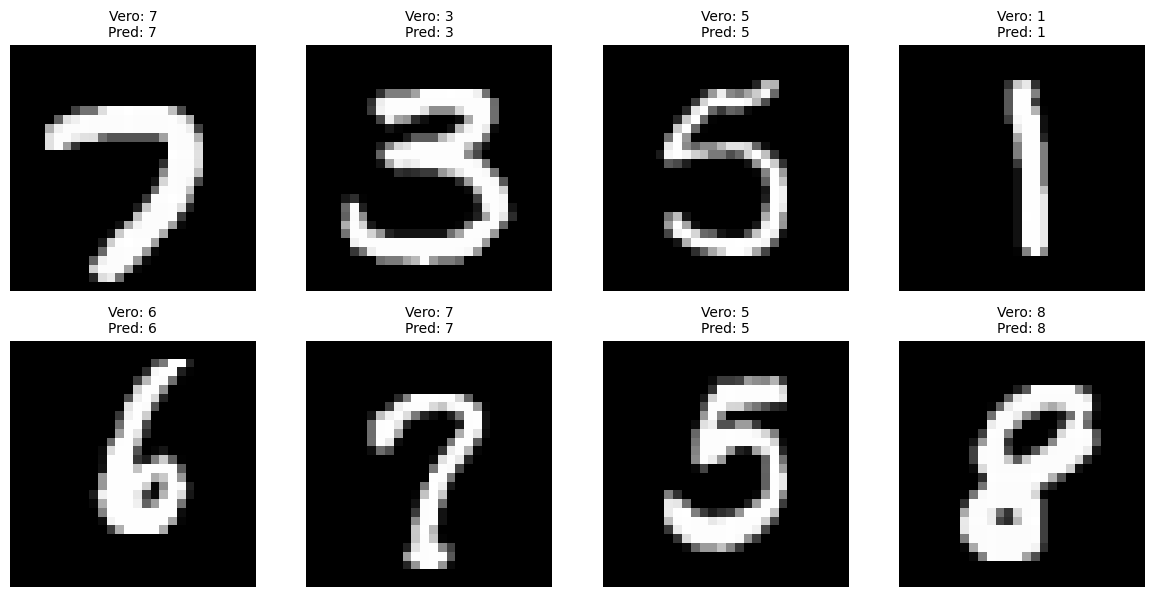

In [33]:
# Scegli 16 indici casuali dal test set
indices = random.sample(range(x_test.shape[0]), 8)

# Crea una figura con 4 righe e 4 colonne
plt.figure(figsize=(12, 12))

for i, idx in enumerate(indices):
    img = x_test[idx]
    label = y_test[idx]

    # Predizione del modello
    pred = model.predict(img.reshape(1, -1))
    predicted_label = np.argmax(pred, axis=1)[0]

    # Aggiungi subplot
    plt.subplot(4, 4, i + 1)
    plt.imshow(img.reshape(28, 28), cmap='gray')
    plt.title(f"Vero: {label}\nPred: {predicted_label}", fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

### 8.3 Matrice di Confusione

Per analizzare meglio gli **errori di classificazione**, possiamo costruire una **matrice di confusione**.

In una matrice di confusione:
- Le righe rappresentano le **etichette vere** (i valori corretti).
- Le colonne rappresentano le **etichette predette** dal modello.
- Ogni cella \([i, j]\) indica **quante volte** il numero **i** è stato classificato come **j**.

L'ideale sarebbe avere **valori alti solo sulla diagonale**, che indica predizioni corrette. I valori **fuori diagonale** sono invece **errori del modello**, che possiamo analizzare per capire dove sbaglia di più.
Note:
- `np.argmax(y_pred, axis=1)` restituisce l'indice della classe più probabile per ciascuna predizione.
- `confusion_matrix` è di `sklearn.metrics`.
- `seaborn.heatmap` viene usato per visualizzare la matrice in modo più leggibile e colorato.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 967us/step


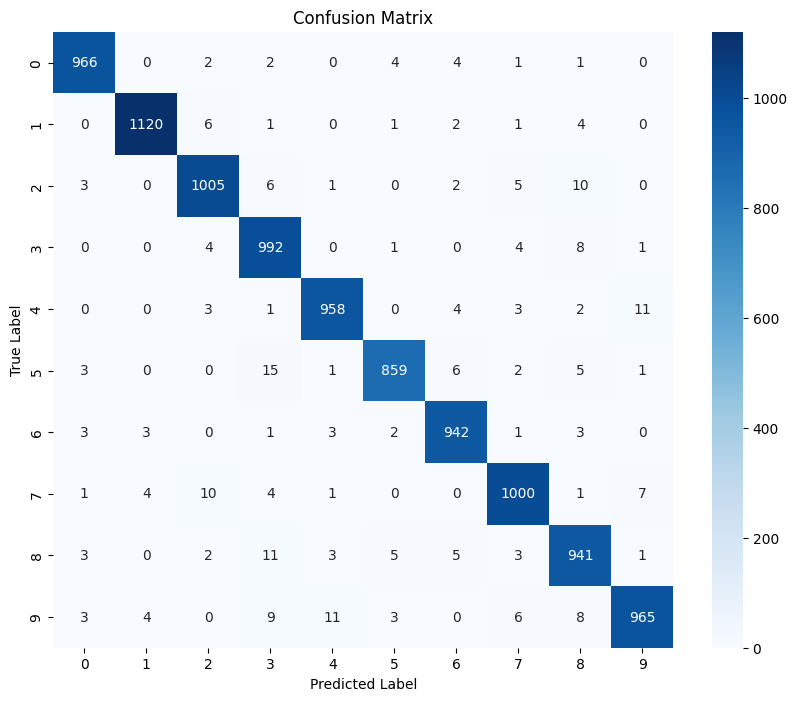

In [14]:
# Otteniamo le predizioni del modello (classe con probabilità più alta)
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Creiamo la matrice di confusione
conf_matrix = confusion_matrix(y_test, y_pred_classes)

# Tracciamo la matrice con seaborn
plt.figure(figsize=(10,8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## 9. Conclusioni

Se tutto è andato a buon fine, dovremmo vedere un’**accuracy** sul test set spesso superiore al **95%** anche con questo modello relativamente semplice. Questa accuratezza può ulteriormente aumentare con:
- Più **epoche** di addestramento.
- Maggiori **neuroni** o **strati** nel modello.
- Architetture **convoluzionali** (CNN).

# 10. (Optional) Miglioramento con CNN

**Proviamo a migliorare il risultato utilizzando una Rete Neurale Convoluzionale (CNN)**

Le CNN (Convolutional Neural Networks) sono particolarmente adatte per il riconoscimento di immagini perché sfruttano i filtri convoluzionali che estraggono automaticamente caratteristiche importanti dalle immagini (bordi, linee, forme, ecc.). Questo permette di ottenere risultati spesso migliori rispetto ai semplici MLP (Multi-Layer Perceptron), soprattutto su dati con struttura 2D come MNIST.


In [15]:
# ====================
# Miglioramento con CNN
# ====================

# Creiamo un nuovo modello che utilizzi layer convoluzionali.
# Per farlo, "ricostruiamo" le immagini 28x28 (in 1 canale, essendo in bianco e nero)
# e applichiamo:
# - 1 layer di convoluzione con 32 filtri di kernel 3x3, seguita da un MaxPooling 2x2
# - 1 layer di convoluzione con 64 filtri di kernel 3x3, seguita da un MaxPooling 2x2
# - Flatten per passare dalla struttura 2D a un vettore 1D
# - 1 Dense hidden layer con 128 neuroni
# - 1 Dense di output con 10 neuroni (uno per ogni cifra) e attivazione softmax

model_cnn = keras.Sequential([
    # 0) Definiamo l'input
    layers.Input(shape=(784,)),  # Definisci l'input qui

    # 1) Ricostruiamo la dimensione immagine (28,28,1) partendo dal vettore 784
    layers.Reshape((28, 28, 1), input_shape=(784,)),

    # 2) Primo strato di convoluzione
    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu'),
    # 3) MaxPooling per ridurre dimensionalità e catturare caratteristiche principali
    layers.MaxPooling2D(pool_size=(2,2)),

    # 4) Secondo strato di convoluzione
    layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    # 5) MaxPooling
    layers.MaxPooling2D(pool_size=(2,2)),

    # 6) Flatten per passare al livello fully connected
    layers.Flatten(),

    # 7) Livello denso (hidden layer) con 128 neuroni
    layers.Dense(128, activation='relu'),

    # 8) Output layer con 10 neuroni e softmax
    layers.Dense(10, activation='softmax')
])

# Compiliamo il modello CNN
model_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(model_cnn.summary())

# Addestriamo la CNN con gli stessi dati di prima
history_cnn = model_cnn.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

# Valutiamo il modello sul test set
test_loss_cnn, test_acc_cnn = model_cnn.evaluate(x_test, y_test, verbose=0)
print(f"Loss sul test set (CNN): {test_loss_cnn:.4f}")
print(f"Accuracy sul test set (CNN): {test_acc_cnn:.4f}")


c:\Users\LuciaGasperini\.virtualenvs\ifab\Lib\site-packages\keras\src\layers\reshaping\reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9487 - loss: 0.1723 - val_accuracy: 0.9870 - val_loss: 0.0490
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9844 - loss: 0.0512 - val_accuracy: 0.9853 - val_loss: 0.0501
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.9891 - loss: 0.0350 - val_accuracy: 0.9883 - val_loss: 0.0455
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9920 - loss: 0.0261 - val_accuracy: 0.9893 - val_loss: 0.0400
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9937 - loss: 0.0195 - val_accuracy: 0.9908 - val_loss: 0.0365
Loss sul test set (CNN): 0.0333
Accuracy sul test set (CNN): 0.9901


### Spiegazione dei principali cambiamenti:
1. **Reshape**: Riconfiguriamo i dati in **(28, 28, 1)** perché la convoluzione si applica a immagini con altezza, larghezza e numero di canali (1 canale in scala di grigi).
2. **Conv2D**: Ogni convoluzione impara dei filtri che “scandagliano” l’immagine per individuare feature come bordi o forme.
3. **MaxPooling2D**: Riduce la dimensione spaziale prendendo il valore massimo in una finestra 2x2, permettendo di focalizzarsi sulle feature più rilevanti (e ridurre la dimensionalità dei dati).
4. **Flatten**: Trasforma i tensori 2D/3D risultanti in un vettore 1D, per poter poi passare a strati densi.
5. **Dense(128)**: Uno strato fully connected con 128 neuroni, che rielabora le feature estratte dai layer convoluzionali.
6. **Dense(10)**: Lo strato finale con 10 neuroni corrisponde alle 10 cifre da classificare (0-9) e l’attivazione `softmax` fornisce le probabilità per ciascuna classe.

Grazie a questa architettura CNN, spesso si ottiene un’**accuratezza superiore** rispetto al semplice MLP, a volte anche vicina al 99%. Se si desidera sperimentare ulteriormente, si possono:
- **Aumentare il numero dei filtri** nei livelli convoluzionali (es. 64 e 128 invece di 32 e 64).
- **Aggiungere uno strato convoluzionale** in più.
- **Incrementare il numero di epoche** di training (es. 10 o più).
- Utilizzare **tecniche di data augmentation** (rotazioni, zoom, traslazioni) per renderla ancora più robusta.